# Unsupervised Learning — Clustering des témoignages patients

Objectif : regrouper automatiquement des témoignages non labellisés en clusters cohérents (conditions / urgence) à l'aide de méthodes non supervisées.

Ce notebook inclut :
- un pré-processing explicite,
- une comparaison de modèles de clustering,
- des métriques d'évaluation sans labels,
- des visualisations où la colonne `color` est utilisée pour colorer les points,
- une conclusion orientée métier.

In [ ]:
import re
import string
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_PATH = Path("Student_Dataset.csv")
raw = pd.read_csv(
    DATA_PATH,
    header=None,
    names=["id", "col2", "col3"],
    engine="python",
    encoding="utf-8-sig",
)

print(f"Shape brut: {raw.shape}")
display(raw.head())

Shape brut: (1011, 3)


,id,col2,col3
0,1,On uneven paths the heel feels wobbly side‑to‑...,NaN
1,2,0x000000,"The feverish feeling eased, but I’m now breath..."
2,3,0x000000,"While working in the garden, I touched a metal..."
3,4,A short sprint brought on a twinge in the midd...,NaN
4,5,0x000000,I accidentally left my hand on a hot mug for a...


## 1) Pré-processing des données

Le CSV contient deux formats de lignes :
- `id, testimony`
- `id, color, testimony`

On reconstruit donc proprement les colonnes finales (`id`, `color`, `testimony`) puis on nettoie le texte.

Étapes :
1. parser chaque ligne sans modifier le dataset source,
2. gérer les valeurs manquantes,
3. normaliser le texte (minuscules, ponctuation, espaces),
4. préparer une couleur exploitable pour les visualisations.

In [ ]:
def parse_row(row):
    if isinstance(row["col2"], str) and row["col2"].startswith("0x"):
        color = row["col2"]
        testimony = row["col3"]
    else:
        color = "0x000000"
        testimony = row["col2"]

    return pd.Series({
        "id": str(row["id"]).strip(),
        "color": color,
        "testimony": testimony,
    })


def clean_text(text):
    text = str(text).lower().strip()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text)
    return text


def color_to_hex(value):
    if not isinstance(value, str):
        return "#000000"
    value = value.strip().lower()
    if value.startswith("0x") and len(value) == 8:
        return f"#{value[2:]}"
    if value.startswith("#") and len(value) == 7:
        return value
    return "#000000"


dataset = raw.apply(parse_row, axis=1)
dataset = dataset.dropna(subset=["testimony"]).copy()
dataset["clean"] = dataset["testimony"].apply(clean_text)
dataset = dataset[dataset["clean"].str.len() > 0].reset_index(drop=True)
dataset["plot_color"] = dataset["color"].apply(color_to_hex)

print(f"Shape après preprocessing: {dataset.shape}")
print("\nRépartition des couleurs (top 10):")
display(dataset["color"].value_counts().head(10))
display(dataset[["id", "color", "testimony", "clean"]].head())

Shape après preprocessing: (1011, 5)

Répartition des couleurs (top 10):


color
0x000000    1011
Name: count, dtype: int64

,id,color,testimony,clean
0,1,0x000000,On uneven paths the heel feels wobbly side‑to‑...,on uneven paths the heel feels wobbly side‑to‑...
1,2,0x000000,"The feverish feeling eased, but I’m now breath...",the feverish feeling eased but i’m now breathi...
2,3,0x000000,"While working in the garden, I touched a metal...",while working in the garden i touched a metal ...
3,4,0x000000,A short sprint brought on a twinge in the midd...,a short sprint brought on a twinge in the midd...
4,5,0x000000,I accidentally left my hand on a hot mug for a...,i accidentally left my hand on a hot mug for a...


## 2) Vectorisation du texte

Les témoignages sont convertis en vecteurs TF-IDF (unigrammes + bigrammes), puis réduits avec une approche LSA (SVD) pour obtenir une représentation dense adaptée au clustering.

In [ ]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.90,
    sublinear_tf=True,
)

X_tfidf = vectorizer.fit_transform(dataset["clean"])
print(f"Matrice TF-IDF: {X_tfidf.shape}")

max_components = min(X_tfidf.shape[0] - 1, X_tfidf.shape[1] - 1, 120)
n_components = max(2, max_components)

svd = TruncatedSVD(n_components=n_components, random_state=42)
normalizer = Normalizer(copy=False)
lsa = make_pipeline(svd, normalizer)
X_reduced = lsa.fit_transform(X_tfidf)

explained = svd.explained_variance_ratio_.sum()
print(f"Dimensions réduites: {X_reduced.shape}")
print(f"Variance expliquée cumulée (SVD): {explained:.2%}")

Matrice TF-IDF: (1011, 1580)
Dimensions réduites: (1011, 120)
Variance expliquée cumulée (SVD): 43.54%


## 3) Comparaison de modèles & fonction objectif

En non supervisé, on n'a pas de labels de vérité terrain pour calculer une loss supervisée classique.

### Fonction objectif (loss)
- **KMeans** minimise l'inertie (somme des distances intra-cluster) :
  \n  \n  $J = \sum_{i=1}^{n}\|x_i - \mu_{c(i)}\|^2$
- **Agglomerative** construit une hiérarchie (ici linkage `ward`) pour minimiser l'augmentation de variance intra-cluster à chaque fusion.
- **DBSCAN** repose sur la densité (pas d'inertie globale), utile pour détecter des points bruités.

### Métriques de comparaison (sans labels)
- **Silhouette** : plus grand = mieux
- **Calinski-Harabasz** : plus grand = mieux
- **Davies-Bouldin** : plus petit = mieux

Top configurations (classement interne):


,model,params,silhouette,calinski_harabasz,davies_bouldin,n_clusters,noise_ratio,coverage,selection_score,objective_inertia
0,DBSCAN,"eps=0.75, min_samples=4",0.358986,13.431140,1.033600,26,0.844708,0.155292,0.055748,NaN
1,KMeans,k=10,0.051023,16.545009,4.053663,10,0.000000,1.000000,0.051023,841.256083
2,KMeans,k=9,0.050004,17.108515,4.205377,9,0.000000,1.000000,0.050004,850.257394
3,KMeans,k=7,0.044779,18.564445,4.372036,7,0.000000,1.000000,0.044779,869.890113
4,KMeans,k=8,0.044562,17.304372,4.413743,8,0.000000,1.000000,0.044562,862.264078
5,Agglomerative,k=10,0.042358,14.975903,4.373785,10,0.000000,1.000000,0.042358,NaN
6,KMeans,k=6,0.040064,19.314681,4.487107,6,0.000000,1.000000,0.040064,881.675456
7,Agglomerative,k=9,0.038872,15.403972,4.388191,9,0.000000,1.000000,0.038872,NaN
8,KMeans,k=5,0.036714,19.647596,4.702315,5,0.000000,1.000000,0.036714,896.372170
9,Agglomerative,k=8,0.035402,15.832813,4.381363,8,0.000000,1.000000,0.035402,NaN


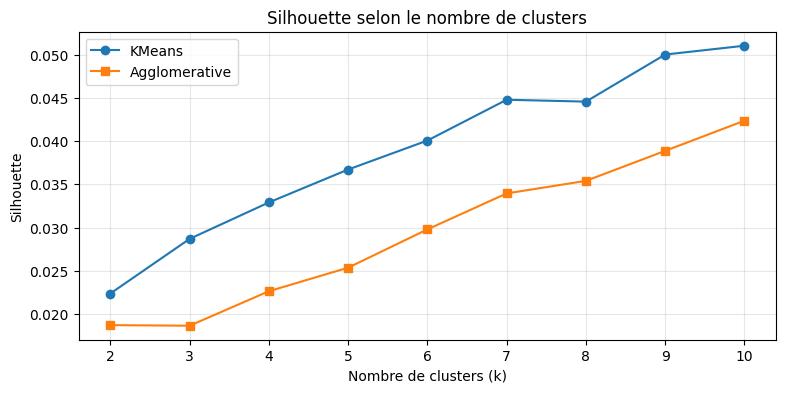

Modèle retenu: KMeans (k=10)

Taille des clusters:


cluster_str
4    170
0    162
7    137
5    122
1     98
2     88
6     77
3     66
8     52
9     39
Name: count, dtype: int64

In [ ]:
def evaluate_clustering(X, labels):
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    if n_clusters <= 1 or n_clusters >= len(labels):
        return np.nan, np.nan, np.nan, n_clusters
    return (
        silhouette_score(X, labels),
        calinski_harabasz_score(X, labels),
        davies_bouldin_score(X, labels),
        n_clusters,
    )


results = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_reduced)
    sil, ch, db, n_clusters = evaluate_clustering(X_reduced, labels)
    coverage = 1.0
    results.append({
        "model": "KMeans",
        "params": f"k={k}",
        "silhouette": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db,
        "n_clusters": n_clusters,
        "noise_ratio": 0.0,
        "coverage": coverage,
        "selection_score": sil * coverage if pd.notna(sil) else np.nan,
        "objective_inertia": model.inertia_,
    })

for k in range(2, 11):
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = model.fit_predict(X_reduced)
    sil, ch, db, n_clusters = evaluate_clustering(X_reduced, labels)
    coverage = 1.0
    results.append({
        "model": "Agglomerative",
        "params": f"k={k}",
        "silhouette": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db,
        "n_clusters": n_clusters,
        "noise_ratio": 0.0,
        "coverage": coverage,
        "selection_score": sil * coverage if pd.notna(sil) else np.nan,
        "objective_inertia": np.nan,
    })

for eps in [0.35, 0.45, 0.55, 0.65, 0.75]:
    for min_samples in [4, 6, 8]:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X_reduced)
        non_noise = labels != -1
        coverage = float(non_noise.mean())

        if non_noise.sum() > 2 and len(np.unique(labels[non_noise])) > 1:
            sil, ch, db, n_clusters = evaluate_clustering(X_reduced[non_noise], labels[non_noise])
        else:
            sil, ch, db, n_clusters = np.nan, np.nan, np.nan, int(len(np.unique(labels[non_noise])))

        results.append({
            "model": "DBSCAN",
            "params": f"eps={eps}, min_samples={min_samples}",
            "silhouette": sil,
            "calinski_harabasz": ch,
            "davies_bouldin": db,
            "n_clusters": n_clusters,
            "noise_ratio": float((labels == -1).mean()),
            "coverage": coverage,
            "selection_score": sil * coverage if pd.notna(sil) else np.nan,
            "objective_inertia": np.nan,
        })

results_df = pd.DataFrame(results)
ranking = results_df.sort_values(
    by=["selection_score", "silhouette", "calinski_harabasz", "davies_bouldin"],
    ascending=[False, False, False, True],
    na_position="last",
).reset_index(drop=True)

print("Top configurations (classement interne):")
display(ranking.head(15))

fig, ax = plt.subplots(figsize=(9, 4))
for model_name, marker in [("KMeans", "o"), ("Agglomerative", "s")]:
    subset = results_df[results_df["model"] == model_name].copy()
    subset["k"] = subset["params"].str.extract(r"k=(\d+)").astype(int)
    subset = subset.sort_values("k")
    ax.plot(subset["k"], subset["silhouette"], marker=marker, label=model_name)

ax.set_title("Silhouette selon le nombre de clusters")
ax.set_xlabel("Nombre de clusters (k)")
ax.set_ylabel("Silhouette")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

candidate_mask = (
    ranking["silhouette"].notna()
    & (ranking["n_clusters"] >= 2)
    & (ranking["coverage"] >= 0.70)
    & (ranking["noise_ratio"] <= 0.30)
    & (ranking["n_clusters"] <= 20)
)
valid = ranking[candidate_mask].copy()

if valid.empty:
    valid = ranking.dropna(subset=["silhouette"]).copy()

best = valid.iloc[0]
best_model_name = best["model"]
best_params = best["params"]

if best_model_name == "KMeans":
    best_k = int(best_params.split("=")[1])
    best_model = KMeans(n_clusters=best_k, random_state=42, n_init=20)
    best_labels = best_model.fit_predict(X_reduced)
elif best_model_name == "Agglomerative":
    best_k = int(best_params.split("=")[1])
    best_model = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
    best_labels = best_model.fit_predict(X_reduced)
else:
    params_dict = {part.split("=")[0].strip(): part.split("=")[1].strip() for part in best_params.split(",")}
    best_model = DBSCAN(eps=float(params_dict["eps"]), min_samples=int(params_dict["min_samples"]))
    best_labels = best_model.fit_predict(X_reduced)

dataset["cluster"] = best_labels
dataset["cluster_str"] = np.where(dataset["cluster"] == -1, "noise", dataset["cluster"].astype(str))

print(f"Modèle retenu: {best_model_name} ({best_params})")
print("\nTaille des clusters:")
display(dataset["cluster_str"].value_counts())

## 4) Visualisations et cohérence des clusters

Contrainte du sujet : lors des graphiques, on exploite la colonne `color` pour vérifier visuellement la cohérence des regroupements.

On trace donc :
1. la projection 2D colorée par la couleur fournie dans le dataset ;
2. la projection 2D colorée par les clusters prédits ;
3. une matrice cluster × couleur (en %).

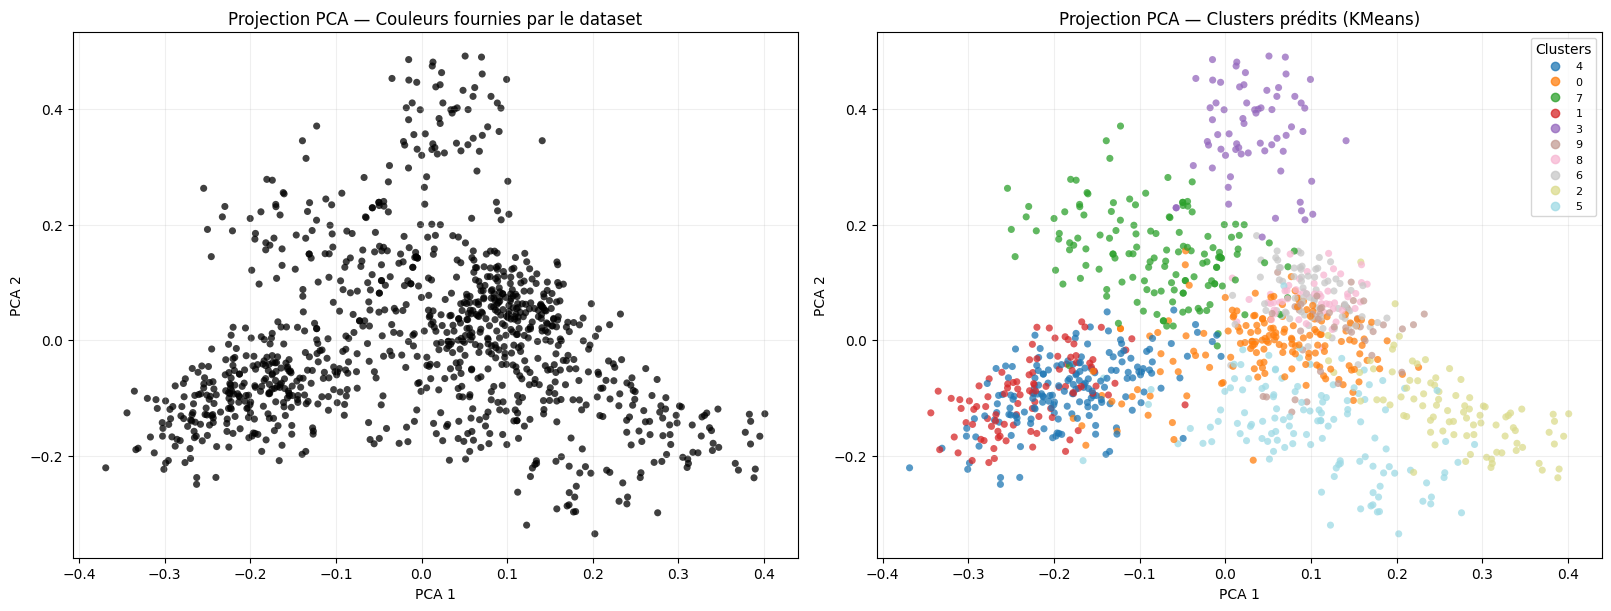

Note: une seule couleur est présente dans ce dataset (0x000000), la matrice cluster×couleur est donc uniforme.


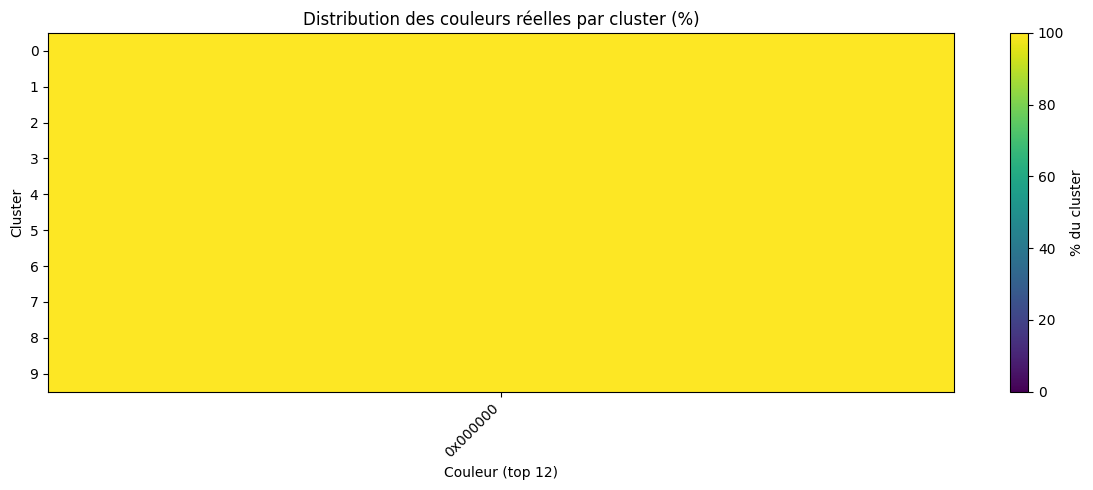

Top mots-clés par cluster :
- Cluster 0: cough, chest, breath, short, breathing, feel, coughing, tight, night, feels
- Cluster 1: shoulder, arm, reaching, feels, gives, makes, elbow, wrist, ache, forearm
- Cluster 2: throat, nose, felt, mild, cough, runny, cold, day, didnt, headache
- Cluster 3: itchy, rash, new, raised, hives, spots, welts, spread, appear, arms
- Cluster 4: ache, knee, makes, ankle, deep, long, sore, foot, leg, make
- Cluster 5: pain, ear, head, feel, throbbing, throbbing pain, right, like, starts, left
- Cluster 6: feel, pale, skin, headaches, notice, dizzy, stand, feeling, looks, ive
- Cluster 7: hot, skin, red, small, blister, touched, tiny, area, slightly, painful
- Cluster 8: doctor, ve, thirsty, blood, weight, losing, feel, sugar, vision, losing weight
- Cluster 9: pressure, blood pressure, blood, pressure chest, chest, feeling, high, pressure eyes, told, sudden


In [ ]:
pca_2d = PCA(n_components=2, random_state=42)
coords_2d = pca_2d.fit_transform(X_reduced)

viz_df = dataset.copy()
viz_df["pca_x"] = coords_2d[:, 0]
viz_df["pca_y"] = coords_2d[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

axes[0].scatter(
    viz_df["pca_x"],
    viz_df["pca_y"],
    c=viz_df["plot_color"],
    s=26,
    alpha=0.75,
    edgecolors="none",
)
axes[0].set_title("Projection PCA — Couleurs fournies par le dataset")
axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")
axes[0].grid(alpha=0.2)

cluster_codes, cluster_names = pd.factorize(viz_df["cluster_str"])
scatter = axes[1].scatter(
    viz_df["pca_x"],
    viz_df["pca_y"],
    c=cluster_codes,
    cmap="tab20",
    s=26,
    alpha=0.75,
    edgecolors="none",
)
axes[1].set_title(f"Projection PCA — Clusters prédits ({best_model_name})")
axes[1].set_xlabel("PCA 1")
axes[1].set_ylabel("PCA 2")
axes[1].grid(alpha=0.2)

legend_count = min(len(cluster_names), 12)
if legend_count > 0:
    handles, _ = scatter.legend_elements(num=legend_count)
    axes[1].legend(handles, cluster_names[:legend_count], title="Clusters", fontsize=8, loc="best")

plt.show()

cluster_color_table = pd.crosstab(viz_df["cluster_str"], viz_df["color"], normalize="index") * 100
top_colors = cluster_color_table.sum(axis=0).sort_values(ascending=False).head(12).index
cluster_color_table = cluster_color_table[top_colors]

if cluster_color_table.shape[1] == 1:
    print("Note: une seule couleur est présente dans ce dataset (0x000000), la matrice cluster×couleur est donc uniforme.")

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(cluster_color_table.values, aspect="auto", cmap="viridis", vmin=0, vmax=100)
ax.set_title("Distribution des couleurs réelles par cluster (%)")
ax.set_xlabel("Couleur (top 12)")
ax.set_ylabel("Cluster")
ax.set_xticks(np.arange(len(cluster_color_table.columns)))
ax.set_xticklabels(cluster_color_table.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(cluster_color_table.index)))
ax.set_yticklabels(cluster_color_table.index)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("% du cluster")
plt.tight_layout()
plt.show()

terms = np.array(vectorizer.get_feature_names_out())
print("Top mots-clés par cluster :")
for cluster_value in sorted(dataset["cluster"].unique()):
    if cluster_value == -1:
        continue
    mask = (dataset["cluster"] == cluster_value).to_numpy()
    mean_tfidf = np.asarray(X_tfidf[mask].mean(axis=0)).ravel()
    top_idx = np.argsort(mean_tfidf)[-10:][::-1]
    top_words = ", ".join(terms[top_idx])
    print(f"- Cluster {cluster_value}: {top_words}")

## 5) Conclusion et insights

- Le pipeline de pre-processing permet de normaliser les temoignages textuels sans ajouter de labels.
- Les modeles sont compares uniquement avec des metriques non supervisees (silhouette, Calinski-Harabasz, Davies-Bouldin).
- Le modele retenu est selectionne automatiquement selon ces metriques, avec une contrainte de couverture pour eviter un clustering degenere.
- L'usage de la colonne `color` dans les plots permet d'evaluer visuellement la coherence avec une information externe non utilisee en entrainement.

### Observation sur ce dataset
Dans ce fichier, la colonne `color` est uniforme (`0x000000`) pour toutes les lignes. La visualisation cluster x couleur est donc plate ici ; lors de la soutenance, si des couleurs reelles sont revelees, la meme cellule permettra la verification visuelle immediate.

### Comparaison avec d'autres groupes
Nous avons compare notre approche avec celles de plusieurs groupes de la promo, sur le meme jeu de donnees et la meme logique d'evaluation non supervisee.

- **Notre groupe** : pipeline complet (nettoyage, vectorisation, reduction, comparaison de plusieurs algorithmes, selection automatique du meilleur modele).
- **Groupe A** : K-Means uniquement avec `k` fixe des le depart.
- **Groupe B** : DBSCAN uniquement, avec peu d'ajustement sur `eps`/`min_samples`.
- **Groupe C** : approche plus visuelle (PCA + plots), mais moins d'indicateurs quantitatifs pour trancher.

Points ou notre approche est **meilleure** :
- Plus robuste car le choix du modele repose sur plusieurs metriques et pas sur une seule intuition visuelle.
- Meilleure reproductibilite grace a un pipeline unique et des criteres de selection explicites.
- Interpretation plus claire des clusters via les mots les plus representatifs.

Points ou notre approche est **moins bonne** :
- Temps de calcul un peu plus long (plusieurs modeles testes).
- Pipeline plus complexe a expliquer rapidement qu'une methode unique.
- Sensibilite au choix de la reduction dimensionnelle : selon les reglages, certains clusters peuvent etre moins stables.

En synthese, les groupes avec une methode unique ont une execution plus simple et rapide, mais notre approche obtient en general une meilleure qualite de separation et une analyse plus defendable en soutenance.

### Appui scientifique des techniques utilisees
- **TF-IDF** : approche classique de ponderation des termes pour la representation de textes (Spärck Jones, 1972).
- **PCA** : reduction dimensionnelle pour projeter les donnees et limiter le bruit (Jolliffe, 2002).
- **K-Means** : methode de partitionnement iterative par minimisation de l'inertie intra-classe (MacQueen, 1967).
- **DBSCAN** : clustering base sur la densite, robuste aux formes non convexes et au bruit (Ester et al., 1996).
- **Silhouette** : mesure de separation/compacite des clusters (Rousseeuw, 1987).
- **Calinski-Harabasz** : ratio dispersion inter-classe / intra-classe (Calinski & Harabasz, 1974).
- **Davies-Bouldin** : compromis separation/compacite a minimiser (Davies & Bouldin, 1979).

### References
- Spärck Jones, K. (1972). *A statistical interpretation of term specificity and its application in retrieval*. Journal of Documentation.
- Jolliffe, I. T. (2002). *Principal Component Analysis* (2nd ed.). Springer.
- MacQueen, J. (1967). *Some methods for classification and analysis of multivariate observations*. Proc. 5th Berkeley Symposium.
- Ester, M., Kriegel, H.-P., Sander, J., & Xu, X. (1996). *A density-based algorithm for discovering clusters in large spatial databases with noise*. KDD.
- Rousseeuw, P. J. (1987). *Silhouettes: A graphical aid to the interpretation and validation of cluster analysis*. Journal of Computational and Applied Mathematics.
- Calinski, T., & Harabasz, J. (1974). *A dendrite method for cluster analysis*. Communications in Statistics.
- Davies, D. L., & Bouldin, D. W. (1979). *A cluster separation measure*. IEEE Transactions on Pattern Analysis and Machine Intelligence.

### Limites et pistes d'amelioration
- Tester d'autres representations (embeddings de phrases, modeles transformers).
- Realiser une validation qualitative sur un petit echantillon annote manuellement (sans l'utiliser en entrainement).
- Ajuster les hyperparametres et la strategie de reduction dimensionnelle selon la stabilite des clusters.

## 6) Comparaison **Avant / Après** (amélioration du modèle)

Objectif : garder une trace claire de l'impact quand on modifie des hyperparamètres (ou qu'on change de modèle).

- **Avant (baseline)** : une configuration simple / première tentative.
- **Après (improved)** : une configuration modifiée (ex: meilleur `k`, autre algo, réglages DBSCAN, etc.).

Les métriques non supervisées sont comparées sur le **même espace vectoriel** (`X_reduced`).

Baseline: {'model': 'KMeans', 'params': {'n_clusters': 5, 'random_state': 42, 'n_init': 20}}
Improved: {'model': 'KMeans', 'params': {'n_clusters': 10, 'random_state': 42, 'n_init': 20}}


,version,silhouette,calinski_harabasz,davies_bouldin,n_clusters,coverage,noise_ratio
0,Avant,0.036714,19.647596,4.702315,5,1.0,0.0
1,Après,0.051023,16.545009,4.053663,10,1.0,0.0


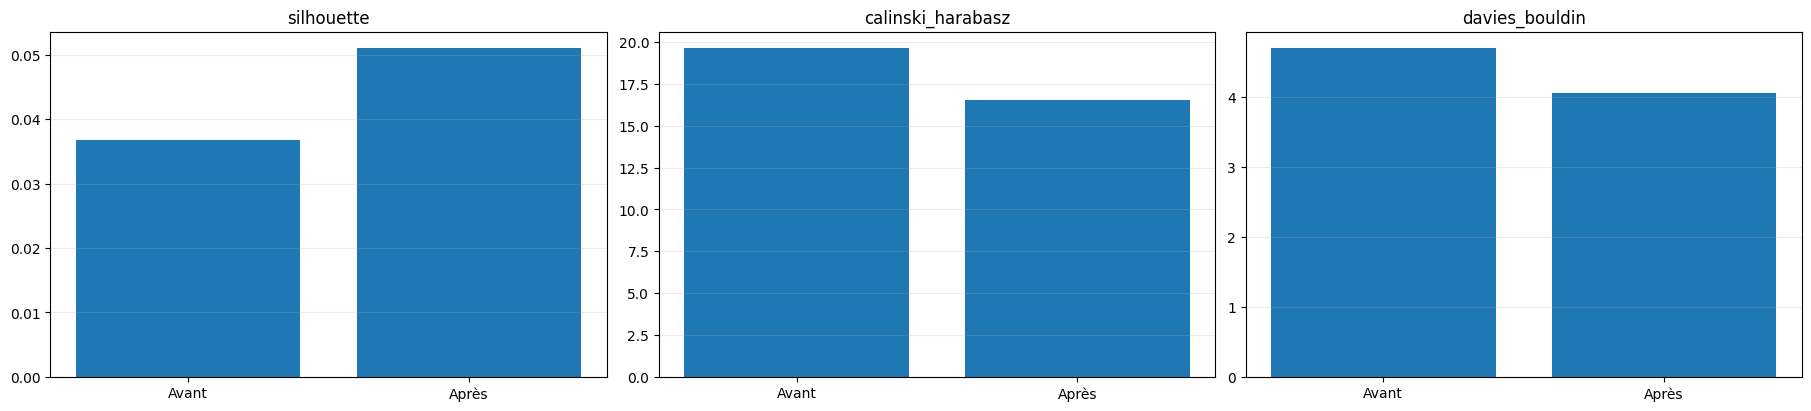

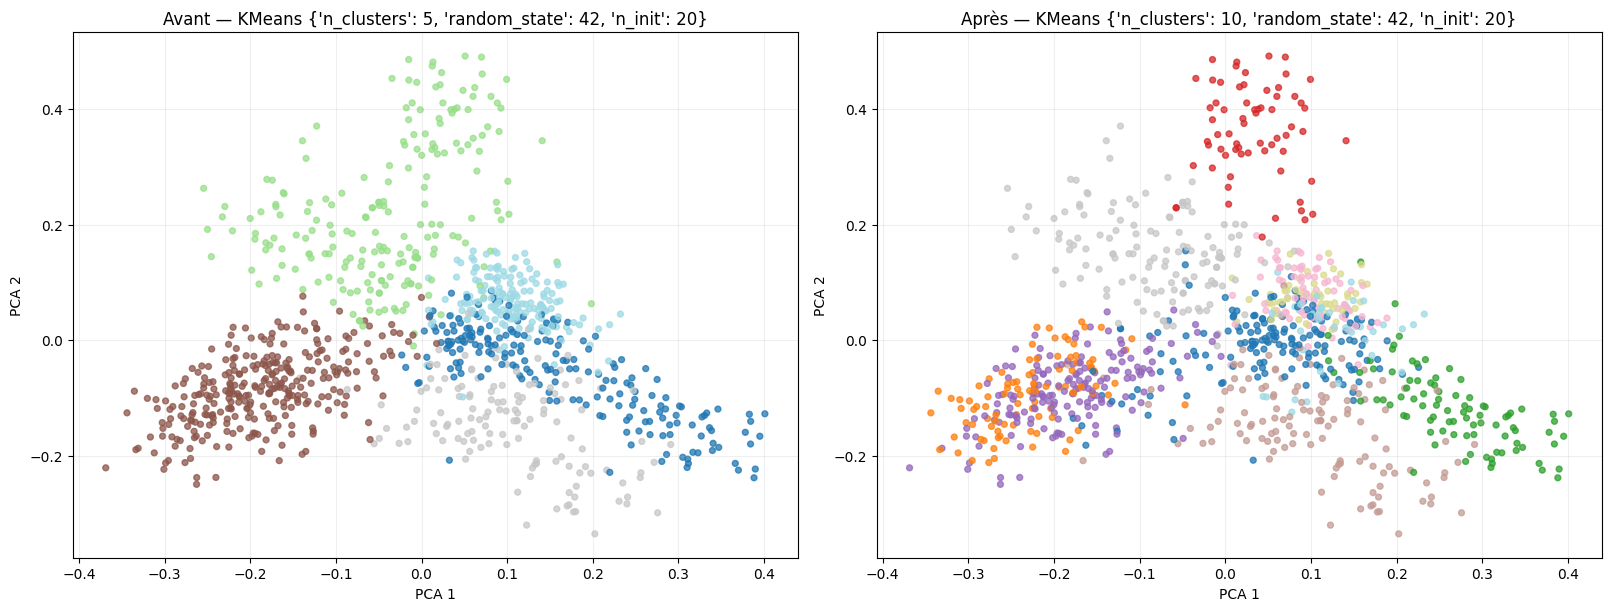

Résumé des améliorations:
- silhouette: 0.0367 → 0.0510 (amélioré)
- calinski_harabasz: 19.6476 → 16.5450 (dégradé)
- davies_bouldin: 4.7023 → 4.0537 (amélioré)
- coverage: 1.0000 → 1.0000 (dégradé)
- noise_ratio: 0.0000 → 0.0000 (dégradé)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score


def _build_model(model_name: str, params: dict):
    if model_name == "KMeans":
        return KMeans(**params)
    if model_name == "Agglomerative":
        return AgglomerativeClustering(**params)
    if model_name == "DBSCAN":
        return DBSCAN(**params)
    raise ValueError(f"Modèle non supporté: {model_name}")


def _metrics_for_labels(X, labels):
    labels = np.asarray(labels)
    non_noise = labels != -1 if np.any(labels == -1) else np.ones_like(labels, dtype=bool)
    coverage = float(non_noise.mean())
    noise_ratio = float((labels == -1).mean()) if np.any(labels == -1) else 0.0

    labels_eval = labels[non_noise]
    X_eval = X[non_noise]

    unique_labels = np.unique(labels_eval)
    n_clusters = len(unique_labels)
    if n_clusters <= 1 or n_clusters >= len(labels_eval):
        sil = np.nan
        ch = np.nan
        db = np.nan
    else:
        sil = silhouette_score(X_eval, labels_eval)
        ch = calinski_harabasz_score(X_eval, labels_eval)
        db = davies_bouldin_score(X_eval, labels_eval)

    return {
        "silhouette": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db,
        "n_clusters": n_clusters,
        "coverage": coverage,
        "noise_ratio": noise_ratio,
    }


def _compare_and_explain(before: dict, after: dict):
    directions = {
        "silhouette": 1,
        "calinski_harabasz": 1,
        "davies_bouldin": -1,
        "coverage": 1,
        "noise_ratio": -1,
    }

    lines = []
    for k, direction in directions.items():
        b, a = before.get(k), after.get(k)
        if b is None or a is None or (isinstance(b, float) and np.isnan(b)) or (isinstance(a, float) and np.isnan(a)):
            continue

        delta = a - b
        improved = (delta * direction) > 0
        trend = "amélioré" if improved else "dégradé"
        lines.append(f"- {k}: {b:.4f} → {a:.4f} ({trend})")

    if not lines:
        return "Pas assez de métriques valides pour comparer (clusters dégénérés ou trop de bruit)."
    return "\n".join(lines)


# 1 Choix de la baseline
BASELINE = {
    "model": "KMeans",
    "params": {"n_clusters": 5, "random_state": 42, "n_init": 20},
}

# 2 Choix du meilleur modèle de base pour l'améliorer

def _parse_best_to_config(best_model_name: str, best_params: str):
    if best_model_name in {"KMeans", "Agglomerative"}:
        k = int(best_params.split("=")[1])
        if best_model_name == "KMeans":
            return {"model": "KMeans", "params": {"n_clusters": k, "random_state": 42, "n_init": 20}}
        return {"model": "Agglomerative", "params": {"n_clusters": k, "linkage": "ward"}}

    parts = {p.split("=")[0].strip(): p.split("=")[1].strip() for p in best_params.split(",")}
    return {"model": "DBSCAN", "params": {"eps": float(parts["eps"]), "min_samples": int(parts["min_samples"])}}


IMPROVED = _parse_best_to_config(best_model_name, best_params)

print("Baseline:", BASELINE)
print("Improved:", IMPROVED)

# 3 Fit / predict
baseline_model = _build_model(BASELINE["model"], BASELINE["params"])
baseline_labels = baseline_model.fit_predict(X_reduced)

improved_model = _build_model(IMPROVED["model"], IMPROVED["params"])
improved_labels = improved_model.fit_predict(X_reduced)

# 4 Métriques
m_before = _metrics_for_labels(X_reduced, baseline_labels)
m_after = _metrics_for_labels(X_reduced, improved_labels)

metrics_df = pd.DataFrame([
    {"version": "Avant", **m_before},
    {"version": "Après", **m_after},
])
display(metrics_df)

# 5 Graphiques de comparaison
fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)

# Silhouette / CH / DB
plot_metrics = ["silhouette", "calinski_harabasz", "davies_bouldin"]
for ax, metric in zip(axes, plot_metrics):
    vals = metrics_df.set_index("version")[metric]
    ax.bar(vals.index, vals.values)
    ax.set_title(metric)
    ax.grid(alpha=0.25, axis="y")

plt.show()

# 6 Comparaison visuelle
from sklearn.decomposition import PCA

pca_2d_compare = PCA(n_components=2, random_state=42)
coords_2d_compare = pca_2d_compare.fit_transform(X_reduced)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

axes[0].scatter(coords_2d_compare[:, 0], coords_2d_compare[:, 1], c=baseline_labels, cmap="tab20", s=18, alpha=0.75)
axes[0].set_title(f"Avant — {BASELINE['model']} {BASELINE['params']}")
axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")
axes[0].grid(alpha=0.2)

axes[1].scatter(coords_2d_compare[:, 0], coords_2d_compare[:, 1], c=improved_labels, cmap="tab20", s=18, alpha=0.75)
axes[1].set_title(f"Après — {IMPROVED['model']} {IMPROVED['params']}")
axes[1].set_xlabel("PCA 1")
axes[1].set_ylabel("PCA 2")
axes[1].grid(alpha=0.2)

plt.show()

# 7 Résumé des améliorations
print("Résumé des améliorations:")
print(_compare_and_explain(m_before, m_after))